In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

import lightgbm as lgb

In [3]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

In [4]:
train_df = pd.read_parquet("/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/train_normalized_df.parquet")

rank_cols = [col for col in train_df.columns if '_rank' in col]
train_df = train_df.drop(columns=rank_cols)

test_df = pd.read_parquet("/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/test_normalized_df.parquet")

rank_cols = [col for col in test_df.columns if '_rank' in col]
test_df = test_df.drop(columns=rank_cols)

val_df = pd.read_parquet("/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/val_normalized_df.parquet")

rank_cols = [col for col in val_df.columns if '_rank' in col]
val_df = val_df.drop(columns=rank_cols)

In [5]:
feature_cols = [
    c for c in train_df.columns
    if c not in ["date","ticker", "fwd_return_5d"]
]

In [6]:
x_train = train_df[feature_cols]
y_train = train_df["fwd_return_5d"]

x_val = val_df[feature_cols]
y_val = val_df["fwd_return_5d"]

x_test = test_df[feature_cols]
y_test = test_df['fwd_return_5d']

In [7]:
val1 = val_df.copy()

In [8]:
from sklearn.ensemble import RandomForestRegressor

rf1 = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=100,
    n_jobs=-1,
    random_state=42
)

rf1.fit(x_train, y_train)

rf1_pred = rf1.predict(x_val)

val1["rf_alpha"] = rf1_pred

In [9]:
rf_ic = []

for d, grp in val1.groupby("date"):
    
    if grp["rf_alpha"].std() == 0:
        continue
        
    ic = spearmanr(grp["rf_alpha"], grp["fwd_return_5d"])[0]
    rf_ic.append(ic)

rf_ic = np.array(rf_ic)

print("RF Mean IC:", rf_ic.mean())
print("RF IR:", rf_ic.mean() / rf_ic.std())

RF Mean IC: 0.010953425049135239
RF IR: 0.04488975225081808


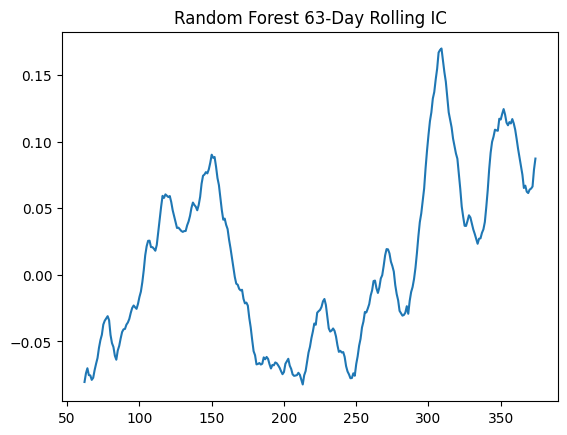

In [10]:
plt.plot(pd.Series(rf_ic).rolling(63).mean())
plt.title("Random Forest 63-Day Rolling IC")
plt.show()

In [11]:
rf_pred = rf1.predict(x_train)

train = train_df.copy()

train["rf_alpha"] = rf_pred

rf_ic = []

for d, grp in train.groupby("date"):
    
    if grp["rf_alpha"].std() == 0:
        continue
        
    ic = spearmanr(grp["rf_alpha"], grp["fwd_return_5d"])[0]
    rf_ic.append(ic)

rf_ic = np.array(rf_ic)

print("RF Mean IC:", rf_ic.mean())
print("RF IR:", rf_ic.mean() / rf_ic.std())

RF Mean IC: 0.06930006284246089
RF IR: 0.3093965073219263


In [12]:
imp = pd.Series(
    rf1.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print(imp.head(10))

vol_63                0.146531
mom_x_vol_63          0.140642
vol_avg_21            0.066678
downside_vol_5d       0.060969
vol_avg_63            0.057770
vol_21                0.055990
price_ma_ratio_63     0.050755
price_ma_ratio_252    0.047426
volume_trend          0.042296
mom_x_vol_21          0.035978
dtype: float64


Unstable but values are significantly higher than LR, so clearly theres a non-linear relationship that RF is able to capture. Also avg. mean IC and low IR means signal exists but is noisy

Gap b/w train and val still exists but smaller comparatively

Observations:

1. Volatility dominates: Most predictive features involve a volatility measure (the high IC features often combine momentum + risk)

2. Nonlinear interactions matter: mom_x_vol_63 and mom_x_vol_21 are non-linear so it explains why LR underperformed

3. Multi-horizon signals: Short-term (21d) vs medium-term (63d) vs long-term (252d) — having different horizons helped the model

---------

Portfolio Construction, Backtesting

--------

In [13]:
import portfolio_cons_backtest
import importlib

importlib.reload(portfolio_cons_backtest)

<module 'portfolio_cons_backtest' from '/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Notebooks/portfolio_cons_backtest.py'>

In [14]:
from portfolio_cons_backtest import *

In [15]:
val_df.columns

Index(['date', 'ticker', 'fwd_return_5d', 'dollar_volume', 'price_ma_ratio_5',
       'price_ma_ratio_10', 'price_ma_ratio_21', 'price_ma_ratio_63',
       'price_ma_ratio_252', 'pos_days_21', 'z_price_21', 'z_price_63',
       'z_return_1d_5', 'z_return_1d_21', 'z_return_1d_35', 'z_return_5d_5',
       'z_return_5d_21', 'z_return_5d_35', 'rev_1d', 'rev_5d', 'vol_5',
       'vol_10', 'vol_21', 'vol_63', 'vol_ratio_21_63', 'vol_ratio_5_21',
       'hl_range', 'downside_vol_1d', 'downside_vol_5d', 'vol_avg_5',
       'vol_avg_21', 'vol_avg_63', 'dollar_vol_log', 'volume_trend',
       'mom_x_vol_5', 'mom_x_vol_21', 'mom_x_vol_63'],
      dtype='object')

In [16]:
val1.columns

Index(['date', 'ticker', 'fwd_return_5d', 'dollar_volume', 'price_ma_ratio_5',
       'price_ma_ratio_10', 'price_ma_ratio_21', 'price_ma_ratio_63',
       'price_ma_ratio_252', 'pos_days_21', 'z_price_21', 'z_price_63',
       'z_return_1d_5', 'z_return_1d_21', 'z_return_1d_35', 'z_return_5d_5',
       'z_return_5d_21', 'z_return_5d_35', 'rev_1d', 'rev_5d', 'vol_5',
       'vol_10', 'vol_21', 'vol_63', 'vol_ratio_21_63', 'vol_ratio_5_21',
       'hl_range', 'downside_vol_1d', 'downside_vol_5d', 'vol_avg_5',
       'vol_avg_21', 'vol_avg_63', 'dollar_vol_log', 'volume_trend',
       'mom_x_vol_5', 'mom_x_vol_21', 'mom_x_vol_63', 'rf_alpha'],
      dtype='object')

Weekly Rebalancing Setup:
  Original: 375 dates
  Weekly: 75 dates



Position sum check (should be ~0): 0.000000


/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Notebooks/portfolio_cons_backtest.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11

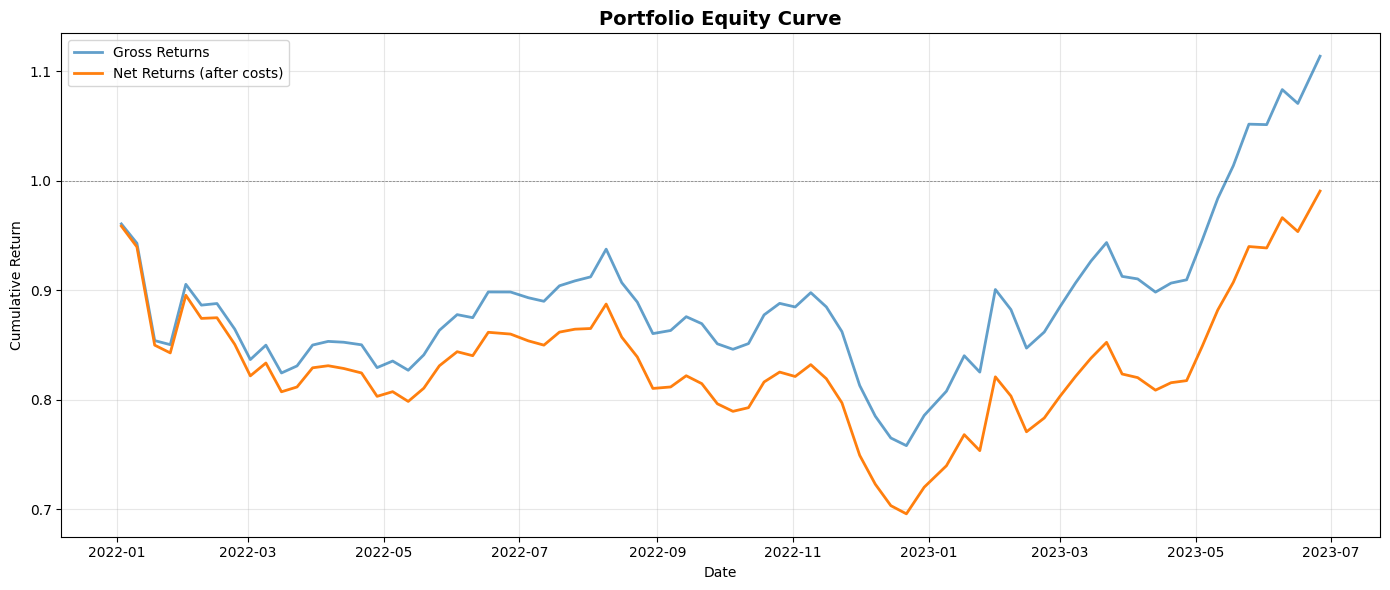

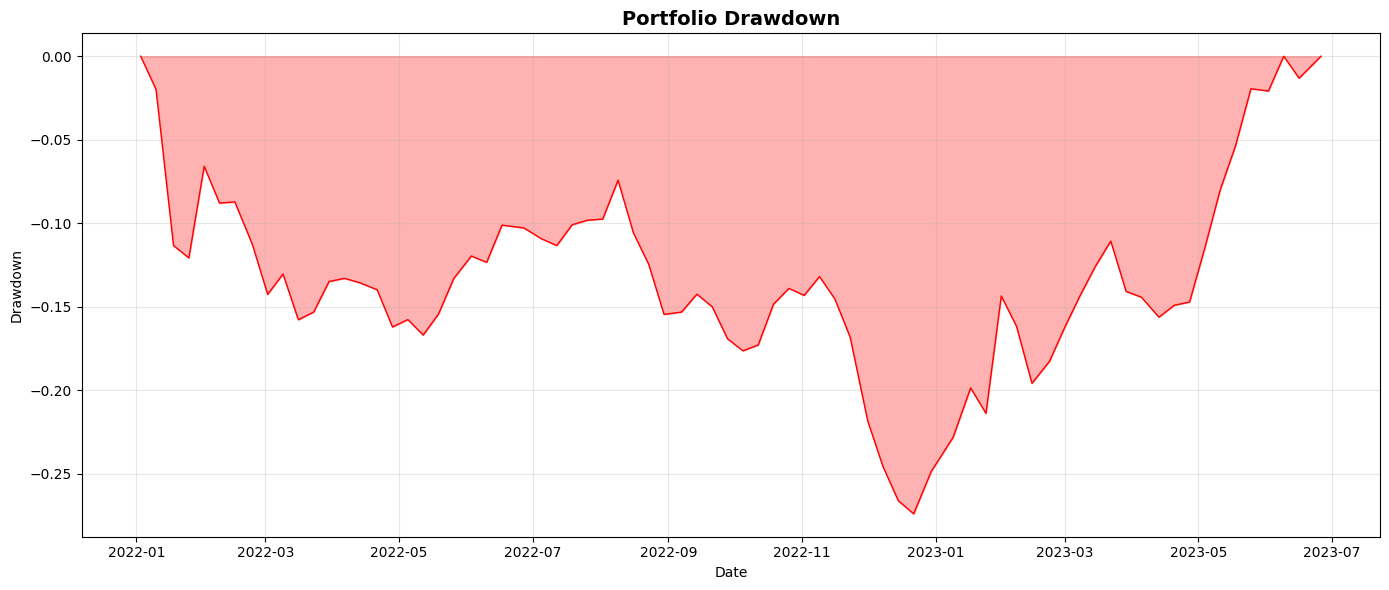

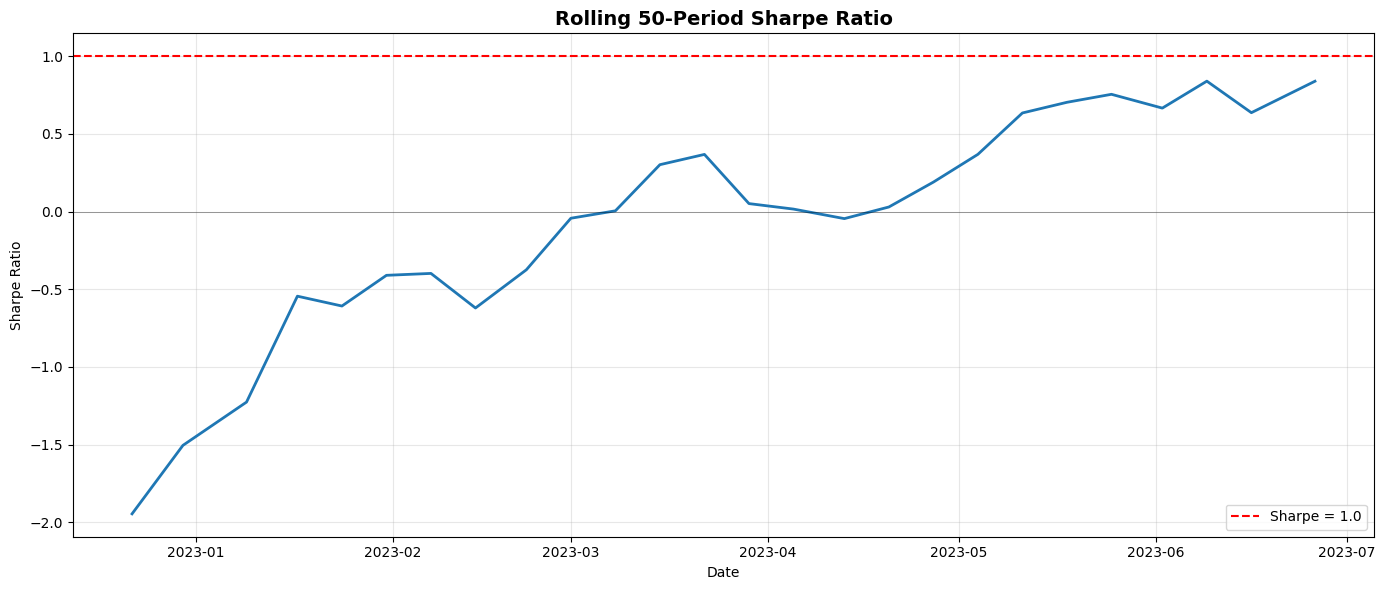

In [17]:
def perf_pipeline(val_df):
    
    val_df = construct_portfolio(val_df, pred_col='rf_alpha', top_pct=0.2, bottom_pct=0.2)

    portfolio_returns = stock_pnl_and_returns(val_df)

    portfolio_returns = turnover(val_df, portfolio_returns)

    portfolio_returns = apply_transaction_costs(portfolio_returns)

    metrics = performance_metrics(portfolio_returns, return_col='net_return', freq=52)
    
    plots(portfolio_returns)
    
    return portfolio_returns, metrics

val1_weekly = filter_weekly(val1)
# Run backtest
portfolio_returns, metrics = perf_pipeline(val1_weekly)

In [18]:
print(metrics)

{'total_return': np.float64(-0.009318341963986732), 'ann_return': np.float64(0.014206775608290626), 'ann_vol': np.float64(0.20451163210903206), 'sharpe': np.float64(0.06946683404646888), 'max_drawdown': np.float64(-0.2740789698042621), 'win_rate': np.float64(0.5066666666666667), 'avg_turnover': np.float64(1.5625925925925928), 'avg_cost': np.float64(0.0015625925925925926), 'n_periods': 75}


On test performance

In [19]:
test1 = test_df.copy()

rf1_pred = rf1.predict(x_test)

test1["rf_alpha"] = rf1_pred

Weekly Rebalancing Setup:
  Original: 356 dates
  Weekly: 72 dates

Position sum check (should be ~0): 0.000000


/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Notebooks/portfolio_cons_backtest.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11

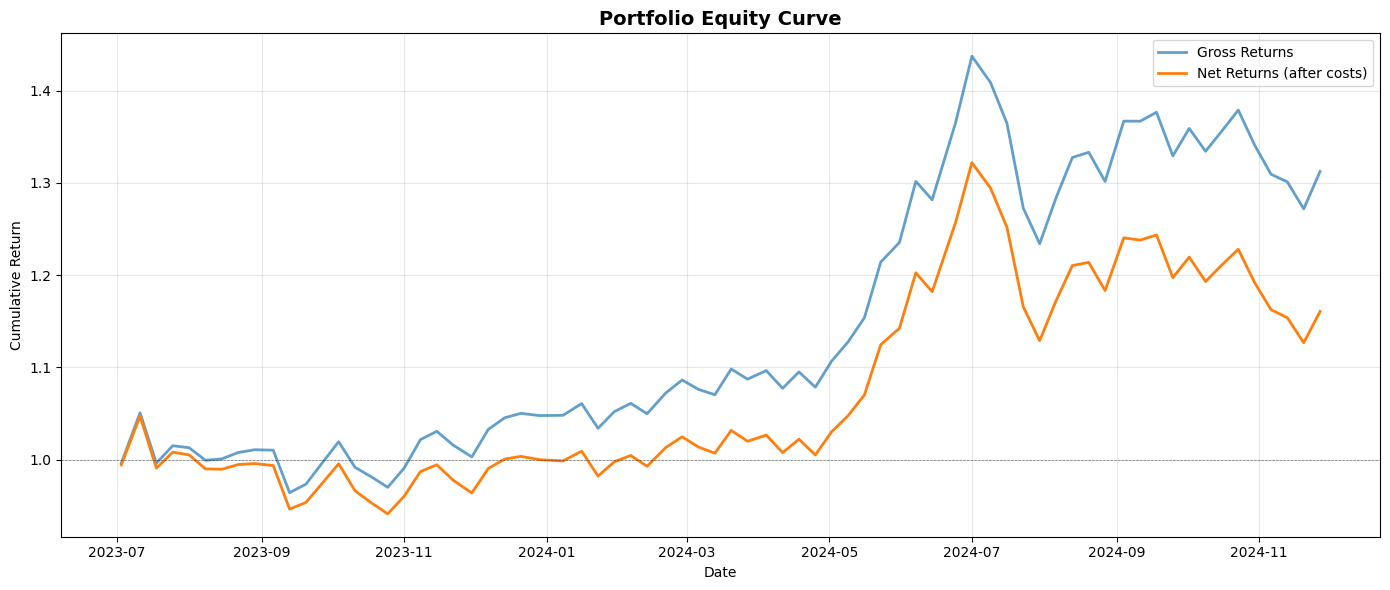

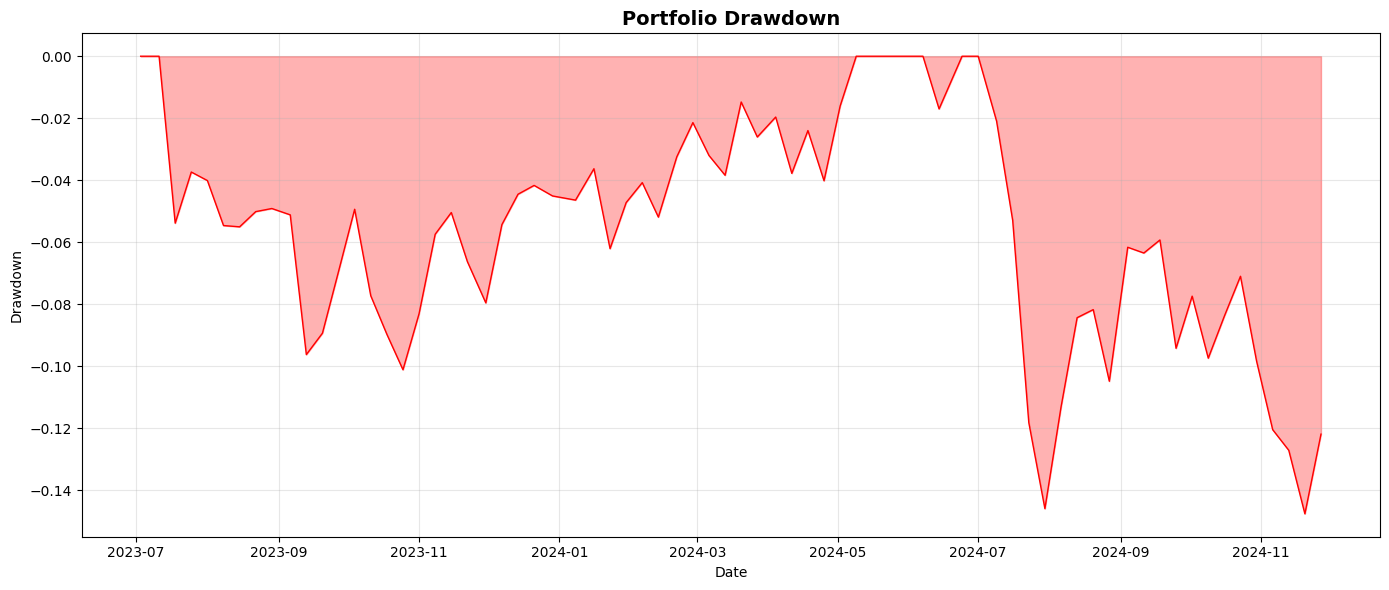

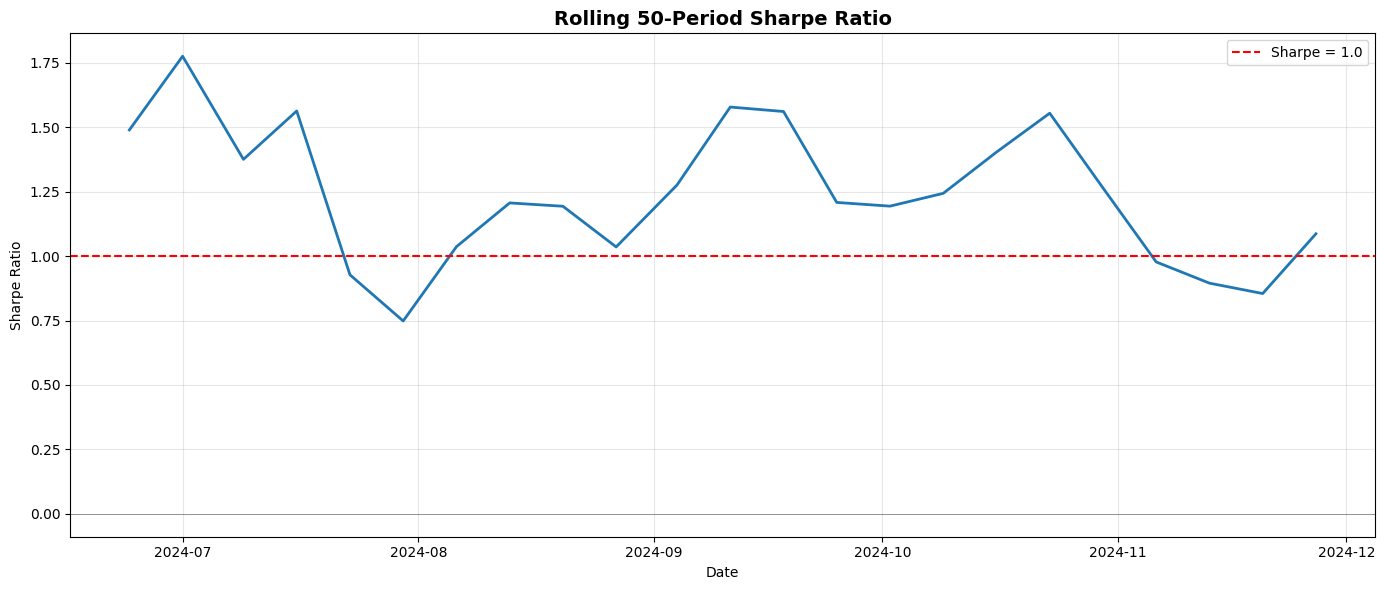

In [20]:
def perf_pipeline(df):
    
    df = construct_portfolio(df, pred_col='rf_alpha', top_pct=0.2, bottom_pct=0.2)

    portfolio_returns = stock_pnl_and_returns(df)

    portfolio_returns = turnover(df, portfolio_returns)

    portfolio_returns = apply_transaction_costs(portfolio_returns)

    metrics = performance_metrics(portfolio_returns, return_col='net_return', freq=52)
    
    plots(portfolio_returns)
    
    return portfolio_returns, metrics

test1_weekly = filter_weekly(test1)
# Run backtest
portfolio_returns, metrics = perf_pipeline(test1_weekly)

In [21]:
print(metrics)

{'total_return': np.float64(0.16077468146131535), 'ann_return': np.float64(0.1254100711179792), 'ann_vol': np.float64(0.18917964927727512), 'sharpe': np.float64(0.6629152321461876), 'max_drawdown': np.float64(-0.14761437491805926), 'win_rate': np.float64(0.5277777777777778), 'avg_turnover': np.float64(1.7098765432098764), 'avg_cost': np.float64(0.0017098765432098765), 'n_periods': 72}


-----

Finetuning the Random Forest model

---------

In [22]:
def calculate_ic(predictions, df_subset):
    
    temp_df = df_subset.copy()
    temp_df['prediction'] = predictions
    
    ic_by_date = temp_df.groupby('date').apply(
        lambda x: spearmanr(x['prediction'], x['fwd_return_5d'])[0]
        if len(x) >= 10 and x['prediction'].std() > 0
        else np.nan
    )
    
    return ic_by_date.mean()

In [ ]:
from tqdm import tqdm
from sklearn.model_selection import ParameterGrid

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5],
    'bootstrap': [True]
}

results = []

for params in tqdm(ParameterGrid(param_grid), desc='Tuning'):
    
    rf_model = RandomForestRegressor(
    **params,
    random_state=42,
    n_jobs=-1
    )
    
    rf_model.fit(x_train, y_train)
    
    predictions = rf_model.predict(x_val)
    val_ic = calculate_ic(predictions, val_df)
    
    # Store results
    result = params.copy()
    result['val_ic'] = val_ic
    result['n_estimators_used'] = rf_model.best_iteration_ if hasattr(rf_model, 'best_iteration_') else 100
    
    results.append(result)

In [24]:
#import joblib

#joblib.dump(rf_model, "rf_model.pkl")


#To load again:

import joblib

rf_model = joblib.load("rf_model.pkl")

In [25]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values('val_ic', ascending=False)

print("TOP 10 PARAMETER COMBINATIONS")

print(results_df.head(10).to_string(index=False))

TOP 10 PARAMETER COMBINATIONS
 bootstrap  max_depth max_features  min_samples_leaf  min_samples_split  n_estimators   val_ic  n_estimators_used
      True          3          0.5                 1                 20           100 0.037904                100
      True          3          0.5                 1                 10           300 0.036890                100
      True          3          0.5                 1                  2           500 0.036679                100
      True          3          0.5                 1                  2           100 0.036603                100
      True          3          0.5                 1                 10           100 0.036267                100
      True          3          0.5                 1                  2           300 0.035983                100
      True          3          0.5                 1                 10           500 0.035097                100
      True          3         log2                 1      

In [26]:
best_params = results_df.iloc[0].to_dict()
best_ic = best_params.pop('val_ic')

In [27]:
best_params

{'bootstrap': True,
 'max_depth': 3,
 'max_features': 0.5,
 'min_samples_leaf': 1,
 'min_samples_split': 20,
 'n_estimators': 100,
 'n_estimators_used': 100}

In [28]:
del best_params['n_estimators_used']
best_params

{'bootstrap': True,
 'max_depth': 3,
 'max_features': 0.5,
 'min_samples_leaf': 1,
 'min_samples_split': 20,
 'n_estimators': 100}

In [29]:
for k in ['max_depth']:
    if k in best_params:
        best_params[k] = int(best_params[k])
    
best_params

{'bootstrap': True,
 'max_depth': 3,
 'max_features': 0.5,
 'min_samples_leaf': 1,
 'min_samples_split': 20,
 'n_estimators': 100}

In [30]:
best_ic

0.03790362949190468

In [31]:
rf_final_model = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
    )

# Train on full training set
rf_final_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [32]:
test2 = test_df.copy()

rf2_pred = rf_final_model.predict(x_test)

test2["rf_alpha"] = rf2_pred

Weekly Rebalancing Setup:
  Original: 356 dates
  Weekly: 72 dates

Position sum check (should be ~0): 0.000000


/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Notebooks/portfolio_cons_backtest.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11

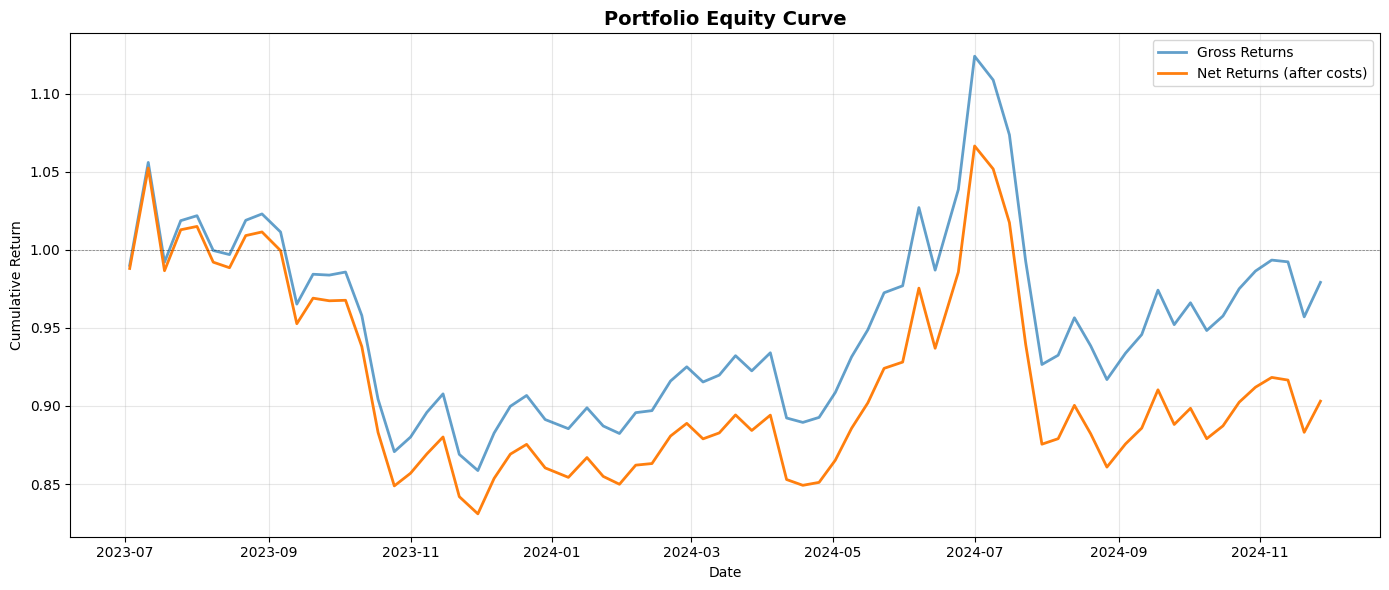

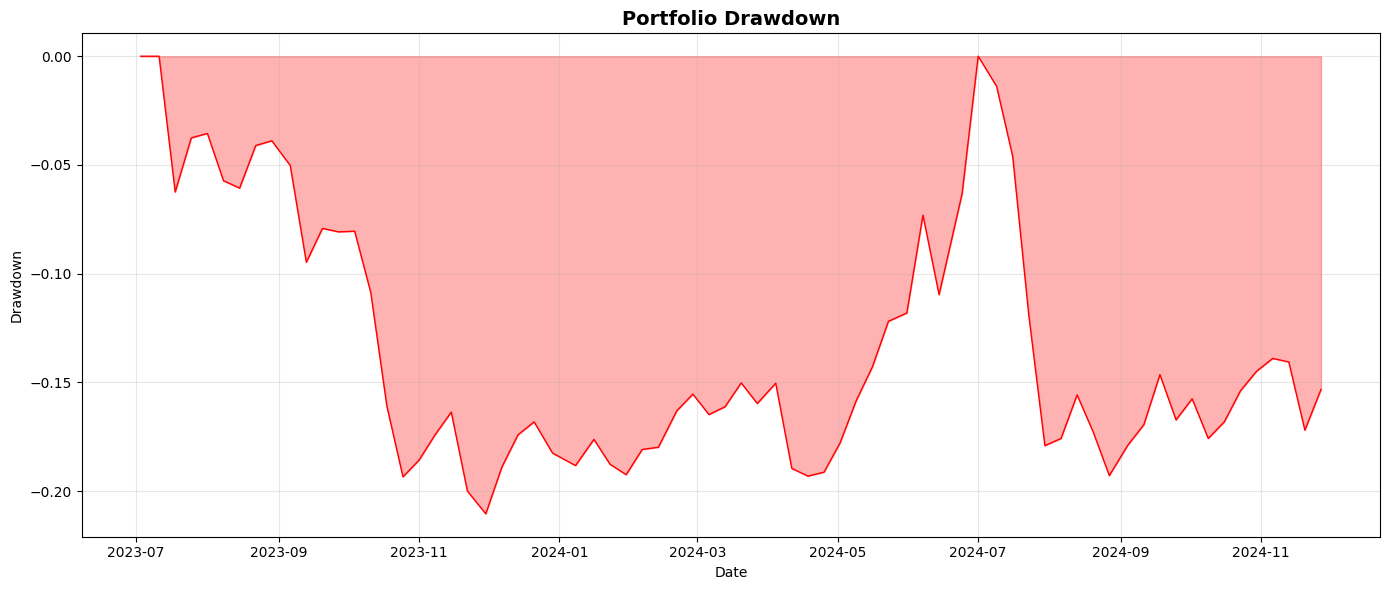

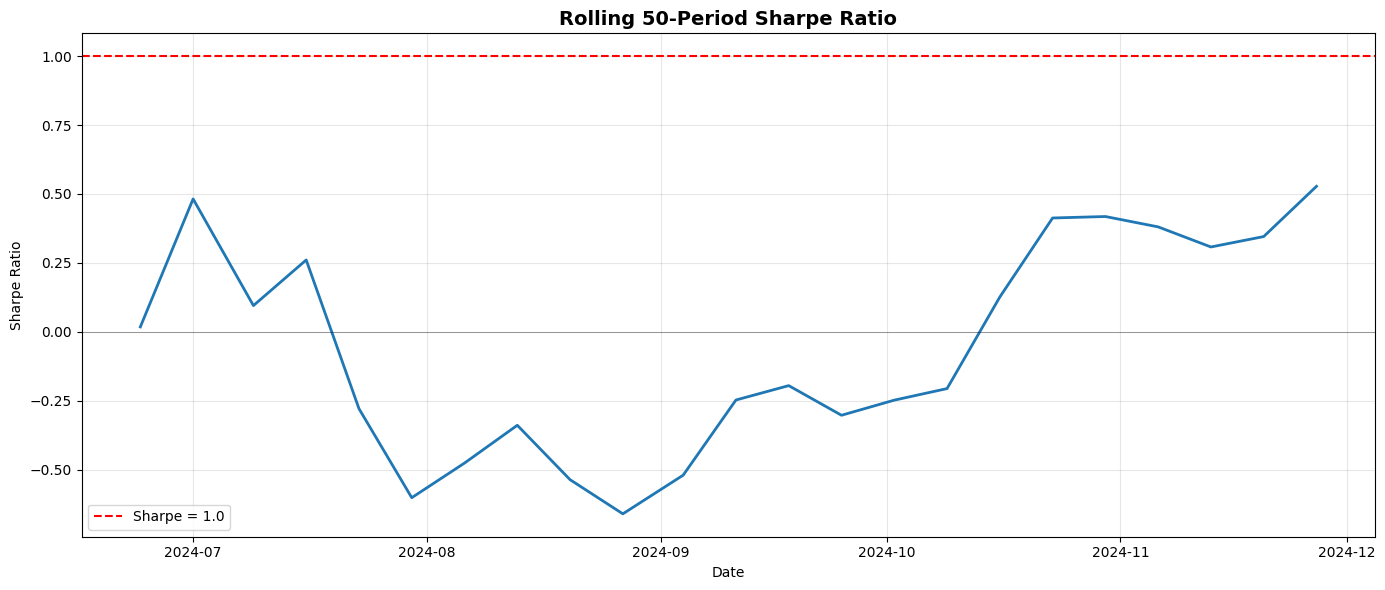

In [33]:
test2_weekly = filter_weekly(test2)
# Run backtest
portfolio_returns, metrics = perf_pipeline(test2_weekly)


In [34]:
print(metrics)

{'total_return': np.float64(-0.09691017153869474), 'ann_return': np.float64(-0.0518477491596174), 'ann_vol': np.float64(0.20923779019329286), 'sharpe': np.float64(-0.2477934273331825), 'max_drawdown': np.float64(-0.21042571972123358), 'win_rate': np.float64(0.5694444444444444), 'avg_turnover': np.float64(1.117283950617284), 'avg_cost': np.float64(0.0011172839506172838), 'n_periods': 72}


---------